<h1 style="text-align: center;">TP4 - Projeto de Bloco: Ciência da Computação</h1>

| 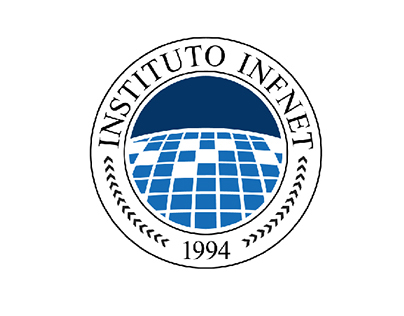 |
|:-------------------------------------------------------------------------:|


<h5 style="text-align: center;">Professor: Ricardo Pires Mesquita || Estudante: Paulo Henrique de Paula Dias</h5>

<h5 style="text-align: center;">Data limite: 27/05/2026</h5>

##### Links úteis:

Repositório Git Hub - [Link](https://github.com/PAULOHENRIQUEDEPAULADIAS/Paulo_Dias_PBCC_TP4_JP)

OBS: Este projeto foi executado sequencialmente.

### Exercício 1

O gráfico a seguir representa o ciclo de tarefas (processos) em um sistema
operacional:

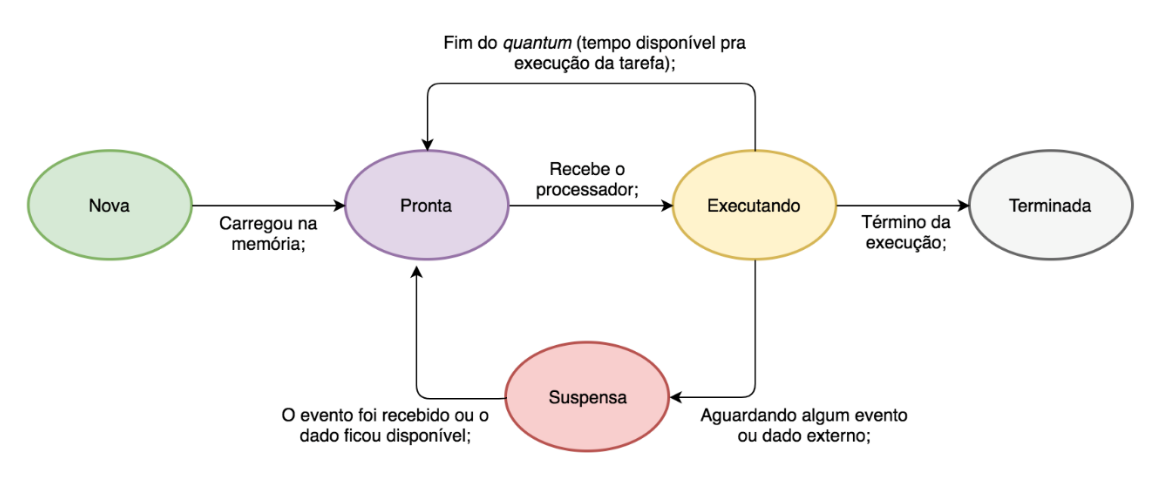


**Onde:**
* “Nova” representa uma tarefa que acabou de chegar para concorrer pela
CPU.
* “Pronta” (ready queue) é uma fila de prioridades que organiza as tarefas
prontas para serem atribuídas à CPU, ou seja, tarefas que já têm
disponível tudo o que é necessário para serem executadas.
* “Suspensa” (waiting queue) é uma fila de prioridades que organiza tarefas
que estão aguardando algum tipo de recurso ou dado para serem levadas
para a ready queue.
* “Executando” representa uma tarefa atribuída, no momento, à CPU.
* “Terminada” representa a tarefa encerrada.

**Tarefa:**
Escreva um programa que permita executar uma simulação dos ciclos de um conjunto de processos na CPU. Para isso, considere:
* Pelo menos 10 processos com diferentes prioridades, dadas pelos respectivos tempos de surtos de CPU (CPU burst).
* Escolha um quantum que permita que seus processos ocupem a CPU pelo menos 3 vezes.
* Implemente as filas como heaps mínimas.
* o Atenção: implemente manualmente a classe heap e as funções necessárias para sua manutenção.
* Temporize as passagens pela CPU (em execução) para passar a impressão de tarefas reais sendo executadas.
* Apresente na saída do programa uma tabela contendo as variações dos estados das estruturas analisadas.
* Documente e apresente os resultados.

In [24]:
import time
import random
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class Processo:
    pid: int
    nome: str
    prioridade: int
    burst_total: int
    burst_restante: int = field(init=False)
    estado:str = "Nova"
    tempo_espera: int = 0
    tempo_retorno: int = 0
    ciclos_cpu: int = 0
    historico: list = field(default_factory=list)

    def __post_init__(self):
        self.burst_restante = self.burst_total

    def __lt__(self, outro):
        return self.prioridade < outro.prioridade

    def __eq__(self, outro):
        return self.prioridade == outro.prioridade

    def mudar_estado(self, novo_estado: str, tick: int):
        self.historico.append((tick, self.estado, novo_estado))
        self.estado = novo_estado


class MinHeap:
    def __init__(self, chave=lambda x:x.prioridade):
        self._dados: list = []
        self._chave = chave

    @staticmethod
    def _pai(i: int) -> int:
        return(i -1) // 2

    @staticmethod
    def _filho_esq(i: int) -> int:
        return 2 * i * 1

    @staticmethod
    def _filho_dir(i: int) -> int:
        return 2 * i * 2

    def _subir(self, i: int):
        while i > 0:
            p = self._pai(i)
            if self._chave(self._dados[i]) < self._chave(self._dados[p]):
                self._dados[i], self._dados[p] = self._dados[p], self._dados[i]
                i = p
            else:
                break

    def _descer(self, i:int):
        n = len(self._dados)
        while True:
            menor = i
            esq = self._filho_esq(i)
            dir = self._filho_dir(i)

            if (esq < n 
                and self._chave(self._dados[esq]) < self._chave(self._dados[menor])):
                menor = esq
            if (dir < n
                and self._chave(self._dados[dir]) < self._chave(self._dados[menor])):
                menor = dir

            if menor != i:
                self._dados[i], self._dados[menor] = self._dados[menor], self._dados[i]
                i = menor
            else:
                break

    def inserir(self, item):
        self._dados.append(item)
        self._subir(len(self._dados) -1)

    def extrair_min(self):
        if self.vazia():
            return None

        self._dados[0], self._dados[-1] = self._dados[-1], self._dados[0]
        minimo = self._dados.pop()
        if not self.vazia():
            self._descer(0)
        return minimo

    def peek(self):
        return self._dados[0] if self._dados else None

    def vazia(self) -> bool:
        return len(self._dados) == 0

    def tamanho(self) -> int:
        return len(self._dados)

    def listar(self) -> list:
        return list(self._dados)

    def __len__(self):
        return len(self._dados)

    def __repr__(self):
        nomes = [f"{p.nome}(P{p.prioridade},B{p.burst_restante})" for p in self._dados]
        return f"MinHeap[{', '.join(nomes)}]"


class Scheduler:
    def __init__(self, quantum: int = 4, velocidade: float = 0.5, prob_suspensao: float = 0.25):
        self.quantum = quantum
        self.velocidade = velocidade
        self.prob_suspensao = prob_suspensao

        self.fila_pronta = MinHeap(chave=lambda p: p.prioridade)
        self.fila_suspensa = MinHeap(chave=lambda p: p.prioridade)
        self.executando: Optional[Processo] = None
        self.terminados: list[Processo] = []
        self.novos: list[Processo] = []

        self.tick = 0
        self.log: list[dict] = []

    def carregar(self, processos: list[Processo]):
        self.novos = list(processos)

    def _snapshot(self, evento: str):
        self.log.append({
            "tick": self.tick,
            "evento": evento,
            "executando": self.executando.nome if self.executando else "-",
            "pronta": [p.nome for p in self.fila_pronta.listar()],
            "suspensa": [p.nome for p in self.fila_suspensa.listar()],
            "terminados": [p.nome for p in self.terminados],
        })

    def _linha(self, msg:str):
        print(f" [tick {self.tick:>4}] {msg}")
    
    def _cabecalho(self, titulo: str):
        print(f"\n{'='*60}")
        print(f" {titulo}")
        print(f"{'='*60}")

    def executar(self):
        self._cabecalho("INÍCIO DA SIMULAÇÃO")

        for p in self.novos:
            p.mudar_estado("Pronta", self.tick)
            self.fila_pronta.inserir(p)
            self._linha(f"-> {p.nome} [Nova -> Pronta] prioridade={p.prioridade} burst={p.burst_total}ms")
            time.sleep(self.velocidade * 0.5)

        self._snapshot("Carga inicial")
        print()

        while not self._tudo_terminado():
            self._verificar_suspensos()

            if self.fila_pronta.vazia():
                self._linha("Fila pronta vazia - aguardando processos suspensos...")
                self.tick += 1
                time.sleep(self.velocidade)
                continue

            processo = self.fila_pronta.extrair_min()
            processo.mudar_estado("Executar", self.tick)
            self.executando = processo

            self._cabecalho(f"CPU -> {processo.nome} (prioridade={processo.prioridade} burst restante={processo.burst_restante}ms)")
            self._snapshot(f"{processo.nome} começa execução")

            tempo_exec = min(self.quantum, processo.burst_restante)
            for ms in range(tempo_exec):
                self.tick += 1
                processo.burst_restante -= 1
                self._linha(f" * {processo.nome} executando... {processo.burst_restante}ms restantes")
                time.sleep(self.velocidade)

            processo.ciclos_cpu += 1
            self.executando = None

            if processo.burst_restante <= 0:
                processo.tempo_retorno = self.tick
                processo.mudar_estado("Terminada", self.tick)
                self.terminados.append(processo)
                self._linha(f"{processo.nome} TERMINADO (retorno={processo.tempo_retorno})")
                self._snapshot(f"{processo.nome} terminou")
            else:
                if random.random() < self.prob_suspensao:
                    processo.mudar_estado("Suspensa", self.tick)
                    self.fila_suspensa.inserir(processo)
                    self._linha(f"{processo.nome} -> Suspensa (aguardando evento)")
                    self._snapshot(f"{processo.nome} suspenso")
    
                else:
                    processo.mudar_estado("Pronta", self.tick)
                    self.fila_pronta.inserir(processo)
                    self._linha(f"{processo.nome} -> Pronta")
                    self._snapshot(f"{processo.nome} voltou pra fila")
    
            for p in self.fila_pronta.listar():
                p.tempo_espera += tempo_exec
    
        self._cabecalho("SIMULAÇÃO CONCLUÍDA")


    def _verificar_suspensos(self):
        liberados = []
        for p in self.fila_suspensa.listar():
            if random.random() < 0.4:
                liberados.append(p)
 
        for p in liberados:
            self.fila_suspensa._dados.remove(p)
            dados = self.fila_suspensa._dados[:]
            self.fila_suspensa._dados = []
            for item in dados:
                self.fila_suspensa.inserir(item)
 
            p.mudar_estado("Pronta", self.tick)
            self.fila_pronta.inserir(p)
            self._linha(f"{p.nome} [Suspensa → Pronta]  evento recebido!")
            self._snapshot(f"{p.nome} saiu da suspensão")
 
    def _tudo_terminado(self) -> bool:
        return (len(self.terminados) == len(self.novos))
 
    def imprimir_tabela(self):
        print(f"\n{'═'*70}")
        print("  TABELA DE RESULTADOS FINAIS")
        print(f"{'═'*70}")
        print(f"  {'Processo':<12} {'Prioridade':>10} {'Burst Total':>11} "
              f"{'Ciclos CPU':>10} {'T. Espera':>10} {'T. Retorno':>11}")
        print(f"  {'-'*65}")
        for p in sorted(self.terminados, key=lambda x: x.pid):
            print(f"  {p.nome:<12} {p.prioridade:>10} {p.burst_total:>11} "
                  f"{p.ciclos_cpu:>10} {p.tempo_espera:>10} {p.tempo_retorno:>11}")
        print(f"{'═'*70}")
 
        espera_media = sum(p.tempo_espera for p in self.terminados) / len(self.terminados)
        retorno_medio = sum(p.tempo_retorno for p in self.terminados) / len(self.terminados)
        ciclos_total = sum(p.ciclos_cpu for p in self.terminados)
        print(f"\n  Espera média   : {espera_media:.1f} ms")
        print(f"  Retorno médio  : {retorno_medio:.1f} ms")
        print(f"  Ciclos de CPU  : {ciclos_total} no total")
        print(f"  Quantum usado  : {self.quantum} ms")
 
    def imprimir_log_estados(self):
        print(f"\n{'═'*70}")
        print("  LOG DE TRANSIÇÕES DE ESTADO")
        print(f"{'═'*70}")
        print(f"  {'Tick':>5}  {'Evento':<35} {'Executando':>12}  "
              f"{'|Pronta|':>8}  {'|Suspensa|':>10}")
        print(f"  {'-'*65}")
        for entrada in self.log:
            print(f"  {entrada['tick']:>5}  {entrada['evento']:<35} "
                  f"{entrada['executando']:>12}  "
                  f"{len(entrada['pronta']):>8}  "
                  f"{len(entrada['suspensa']):>10}")
        print(f"{'═'*70}")
 
def main():
    random.seed(42)
 
    QUANTUM = 4
 
    processos = [
        Processo(pid=1,  nome="P01-Browser",  prioridade=1,  burst_total=15),
        Processo(pid=2,  nome="P02-Editor",   prioridade=3,  burst_total=20),
        Processo(pid=3,  nome="P03-Antivir",  prioridade=8,  burst_total=13),
        Processo(pid=4,  nome="P04-Backup",   prioridade=10, burst_total=25),
        Processo(pid=5,  nome="P05-DB",       prioridade=2,  burst_total=18),
        Processo(pid=6,  nome="P06-Audio",    prioridade=5,  burst_total=14),
        Processo(pid=7,  nome="P07-Compil",   prioridade=4,  burst_total=22),
        Processo(pid=8,  nome="P08-Logger",   prioridade=9,  burst_total=13),
        Processo(pid=9,  nome="P09-Network",  prioridade=6,  burst_total=16),
        Processo(pid=10, nome="P10-Updater",  prioridade=7,  burst_total=19),
    ]
 
    scheduler = Scheduler(quantum=QUANTUM, velocidade=0.03, prob_suspensao=0.2)
    scheduler.carregar(processos)
    scheduler.executar()
    scheduler.imprimir_log_estados()
    scheduler.imprimir_tabela()
 
 
if __name__ == "__main__":
    main()


 INÍCIO DA SIMULAÇÃO
 [tick    0] -> P01-Browser [Nova -> Pronta] prioridade=1 burst=15ms
 [tick    0] -> P02-Editor [Nova -> Pronta] prioridade=3 burst=20ms
 [tick    0] -> P03-Antivir [Nova -> Pronta] prioridade=8 burst=13ms
 [tick    0] -> P04-Backup [Nova -> Pronta] prioridade=10 burst=25ms
 [tick    0] -> P05-DB [Nova -> Pronta] prioridade=2 burst=18ms
 [tick    0] -> P06-Audio [Nova -> Pronta] prioridade=5 burst=14ms
 [tick    0] -> P07-Compil [Nova -> Pronta] prioridade=4 burst=22ms
 [tick    0] -> P08-Logger [Nova -> Pronta] prioridade=9 burst=13ms
 [tick    0] -> P09-Network [Nova -> Pronta] prioridade=6 burst=16ms
 [tick    0] -> P10-Updater [Nova -> Pronta] prioridade=7 burst=19ms


 CPU -> P01-Browser (prioridade=1 burst restante=15ms)
 [tick    1]  * P01-Browser executando... 14ms restantes
 [tick    2]  * P01-Browser executando... 13ms restantes
 [tick    3]  * P01-Browser executando... 12ms restantes
 [tick    4]  * P01-Browser executando... 11ms restantes
 [tick    4] 

### Exercício 2

Implemente uma classe Trie com todos os métodos necessários para sua manutenção e manipulação de palavras. Dentre eles:
* Inserir palavras na Trie.
    * Atenção: sua árvore deverá conter pelo menos as 100 palavras mais comuns da língua portuguesa.
* Trie Search.
* Remover palavras.
* Listar palavras.
* Uma função para autocompletar.
* Uma função para autocorreção.
* Execute uma bateria de testes em seu programa e documente os resultados.

In [1]:
class TrieNode:
    def __init__(self):
        self.is_end = False
        self.di_children = {}

class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word):
        current = self.root

        for char in word:
            if char not in current.di_children:
                current.di_children[char] = TrieNode()

            current = current.di_children[char]

        current.is_end = True

    def search(self, word):
        current = self.root

        for char in word:
            if char not in current.di_children:
                return False


            current = current.di_children[char]
        return current.is_end

    def starts_with(self, prefix):
        current = self.root

        for char in prefix:
            if char not in current.di_children: 
                return False
            
            current = current.di_children[char]
        
        return True
        
    def collect_words(self, node, prefix):
        return self._collect_words(node, prefix)

    def _collect_words(self, node, prefix):
        words = []

        if node.is_end:
            words.append(prefix)

        for char, child_node in node.di_children.items():
            words.extend(self._collect_words(child_node, prefix + char))

        return words

    def autocomplete(self, prefix, k):
        current = self.root

        for char in prefix:
            if char not in current.di_children:
                return []

            current = current.di_children[char]

        words = self.collect_words(current, prefix)

        words.sort()

        return words[:k]

    def autocorrect(self, word):
        if self.search(word):
            return word

        current = self.root
        prefix = ""

        for char in word:
            if char not in current.di_children:
                break

            current = current.di_children[char]
            prefix += char

        suggestions = self.collect_words(current, prefix)

        if not suggestions:
            return None

        suggestions.sort()
        return suggestions[0]


trie = Trie()

words_original = [
    "car",
    "cart",
    "carro",
    "carta",
    "carga",
    "casa",
    "cadeira"
]

for word in words_original:
    trie.insert(word)
    
print(f"Palavras inseridas: {words_original}")
print("")

print(f"Palavra 'car' correta existente: {trie.autocorrect("car")}")
print("")

print(f"Palavra 'carr', com erro ao final: {trie.autocorrect("carr")}")
print("")

print(f"Palavra 'casro', com erro no meio: {trie.autocorrect("casro")}")
print("")

print(f"Palavra 'cabide', prefixo comum: {trie.autocorrect("cabide")}")
print("")

print(f"Empate entre múltiplas palavras 'cargx': {trie.autocorrect("cargx")} ")


Palavras inseridas: ['car', 'cart', 'carro', 'carta', 'carga', 'casa', 'cadeira']

Palavra 'car' correta existente: car

Palavra 'carr', com erro ao final: carro

Palavra 'casro', com erro no meio: casa

Palavra 'cabide', prefixo comum: cadeira

Empate entre múltiplas palavras 'cargx': carga 


### Exercício 3

Considere o seguinte labirinto:

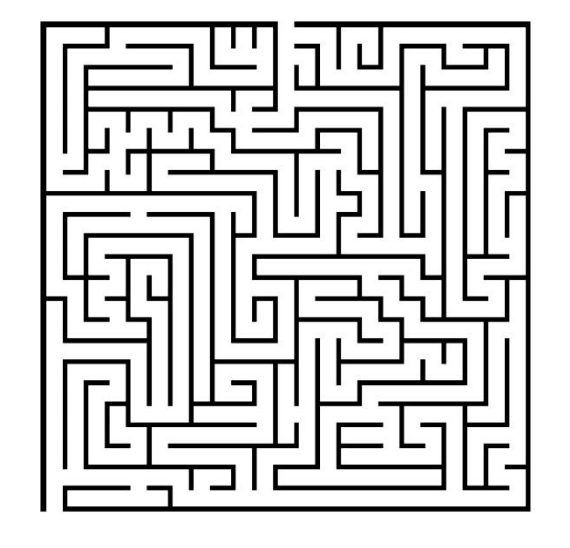

* Crie uma representação computacional para o labirinto Dicas:
    * O labirinto deve ser representado na máquina como um grafo.
    * Considere posicionar os vértices nas posições onde deve haver uma decisão do tipo para onde ir, ou seja, nas portas/passagens.
* Implemente o algoritmo DFS (Depth-First Search) para grafos. (Dica: esse algoritmo utiliza uma pilha como estrutura de dados auxiliar.) Aplique-o para determinar um caminho para a saída do labirinto.
* Implemente o algoritmo BFS (Breadth -First Search) para grafos. (Dica: esse algoritmo utiliza uma fila como estrutura de dados auxiliar.) Aplique-o para determinar um caminho para a saída do labirinto.
* Documente e compare os resultados obtidos nos itens (c) e (d).

In [17]:
from collections import deque

labirinto = [
    "#####################",
    "#   # #  S  # #     #",
    "# # # # ### # # ### #",
    "# #   #   #   #   # #",
    "# ##### # ####### # #",
    "#     # #         # #",
    "##### # ########### #",
    "#   # #   #     #   #",
    "# # # ### # ### # ###",
    "# #   #   #   # #   #",
    "# ##### ####### # # #",
    "#   #       #   # # #",
    "# # # ##### # ### # #",
    "# #       # #   # # #",
    "# # ##### # # # # # #",
    "# #     # # # #   # #",
    "# # ### # # # ##### #",
    "# #   # #   #     # #",
    "# ### # ##### ### # #",
    "#E        #     #   #",
    "#####################",
]

def encontrar(grid, char):
    for i, linha in enumerate(grid):
        for j, cel in enumerate(linha):
            if cel == char:
                return (i, j)

def construir_grafo(grid):
    grafo = {}
    linhas = len(grid)
    colunas = len(grid[0])
    for i in range(linhas):
        for j in range(colunas):
            if grid[i][j] != '#':
                vizinhos = []
                for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < linhas and 0 <= nj < colunas:
                        if grid[ni][nj] != '#':
                            vizinhos.append((ni, nj))
                grafo[(i, j)] = vizinhos
    return grafo

def dfs(grafo, inicio, fim):
    pilha = [(inicio, [inicio])]
    visitados = set()
    while pilha:
        (v, caminho) = pilha.pop()
        if v in visitados:
            continue
        visitados.add(v)
        if v == fim:
            return caminho, len(visitados)
        for viz in grafo[v]:
            if viz not in visitados:
                pilha.append((viz, caminho + [viz]))
    return None, len(visitados)

def bfs(grafo, inicio, fim):
    fila = deque([(inicio, [inicio])])
    visitados = set()
    while fila:
        (v, caminho) = fila.popleft()
        if v in visitados:
            continue
        visitados.add(v)
        if v == fim:
            return caminho, len(visitados)
        for viz in grafo[v]:
            if viz not in visitados:
                fila.append((viz, caminho + [viz]))
    return None, len(visitados)

def imprimir_resultado(nome, caminho, visitados, grid):
    if caminho is None:
        print(f"{nome} — Sem caminho. Vértices visitados: {visitados}")
        return
    print(f"{nome} — Tamanho do caminho: {len(caminho)}, Vértices visitados: {visitados}")
    caminho_set = set(caminho)
    for i, linha in enumerate(grid):
        row = ""
        for j, cel in enumerate(linha):
            if (i, j) in caminho_set and cel not in ('S', 'E'):
                row += '·'
            else:
                row += cel
        print(row)

grafo = construir_grafo(labirinto)
inicio = encontrar(labirinto, 'S')
fim    = encontrar(labirinto, 'E')

caminho_dfs, visitados_dfs = dfs(grafo, inicio, fim)
caminho_bfs, visitados_bfs = bfs(grafo, inicio, fim)

print("=" * 40)
imprimir_resultado("DFS", caminho_dfs, visitados_dfs, labirinto)
print("=" * 40)
imprimir_resultado("BFS", caminho_bfs, visitados_bfs, labirinto)

DFS — Tamanho do caminho: 55, Vértices visitados: 154
#####################
#   # #··S  # #     #
# # # #·### # # ### #
# #   #·  #   #   # #
# #####·# ####### # #
#     #·#         # #
##### #·########### #
#   # #···#     #   #
# # # ###·# ### # ###
# #   #···#   # #   #
# #####·####### # # #
#   #  ·····#   # # #
# # # #####·# ### # #
# #·······#·#   # # #
# #·#####·#·# # # # #
# #·····#·#·# #   # #
# # ###·#·#·# ##### #
# #   #·#···#     # #
# ### #·##### ### # #
#E······  #     #   #
#####################
BFS — Tamanho do caminho: 35, Vértices visitados: 120
#####################
#   # #··S  # #     #
# # # #·### # # ### #
# #   #·  #   #   # #
# #####·# ####### # #
#     #·#         # #
##### #·########### #
#   # #···#     #   #
# # # ###·# ### # ###
# #   #···#   # #   #
# #####·####### # # #
#···#···    #   # # #
#·#·#·##### # ### # #
#·#···    # #   # # #
#·# ##### # # # # # #
#·#     # # # #   # #
#·# ### # # # ##### #
#·#   # #   #     # #
#·### # ##### ### # #
#E        # 

Aqui temos o resultado onde o algorítmo BFS encontra o caminho com menos passos, pois faz a verificação nível à nível antes de seguir. Em contrapartida, o algorítmo DFS se utiliza do recurso de pilhas, percorrendo uma opção de caminho com maior profundidade, e retrocedendo por completo caso não seja o mais adequado.

### Exercício 4

Implemente aplicações cliente e servidor, utilizando o módulo socket, da seguinte maneira:
* Implemente um cliente TCP, usando socket. Instale-o em um computador “A”.
* Implemente um servidor TCP baseado em sockets. Hospede-o em um computador “B”.
* Implemente um cliente UDP, usando socket. Instale-o em um computador “A”.
* Implemente um servidor UDP baseado em sockets. Hospede-o em um computador “B”.
* Execute uma bateria de testes de comunicação entre os clientes e servidores TCP e UDP nos computadores “A” e “B”. (Atenção: naturalmente, os computadores “A” e ”B” deverão estar em rede, acessíveis um ao outro.)
* Documente os resultados.

tcp_client.py

    import socket
    SERVER_IP = '192.168.1.50' # Exemplo de IP do Computador B
    PORT = 8080
    client_tcp = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    client_tcp.connect((SERVER_IP, PORT)) # Realiza o Three-Way Handshake
    msg = "Ola Servidor TCP, testando fluxo de bytes."
    client_tcp.sendall(msg.encode('utf-8'))
    resposta = client_tcp.recv(1024)
    print(f"[Resposta TCP]: {resposta.decode('utf-8')}")
    client_tcp.close()

tcp_server.py

    import socket
    # Configuração: Escuta em todas as interfaces na porta 8080
    HOST = '0.0.0.0'
    PORT = 8080
    # AF_INET = IPv4 | SOCK_STREAM = TCP
    server_tcp = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    server_tcp.bind((HOST, PORT))
    server_tcp.listen(1) # Prontificado para aceitar conexões
    print(f"[*] Servidor TCP aguardando conexão na porta {PORT}...")
        while True:
            # accept() bloqueia a execução esperando um cliente
            client_sock, client_addr = server_tcp.accept()
            print(f"[+] Conexão TCP aceita de {client_addr}")
                try:
                    while True:
                        data = client_sock.recv(1024) # Buffer de 1024 bytes
                        if not data:
                            break # Cliente fechou a conexão de forma limpa
                        mensagem = data.decode('utf-8')
                        print(f"[TCP] Recebido: {mensagem}")
                        # Echo: Devolve o texto em letras maiúsculas
                        client_sock.sendall(f"ECHO: {mensagem.upper()}".encode('utf-8'))
                except ConnectionResetError:
                    print("[-] Cliente desconectado abruptamente.")
                finally:
                    client_sock.close()




Para esta atividade, utilizei o loopback para implementacao, substituindo a porta server por '127.0.0.1'

Atravez do comando 'python3 [nome_arquivo]', executei o servidor, e a seguir, o cliente, chegando na conexao adequada.

Print servidor, que ja recebeu a resposta do cliente:
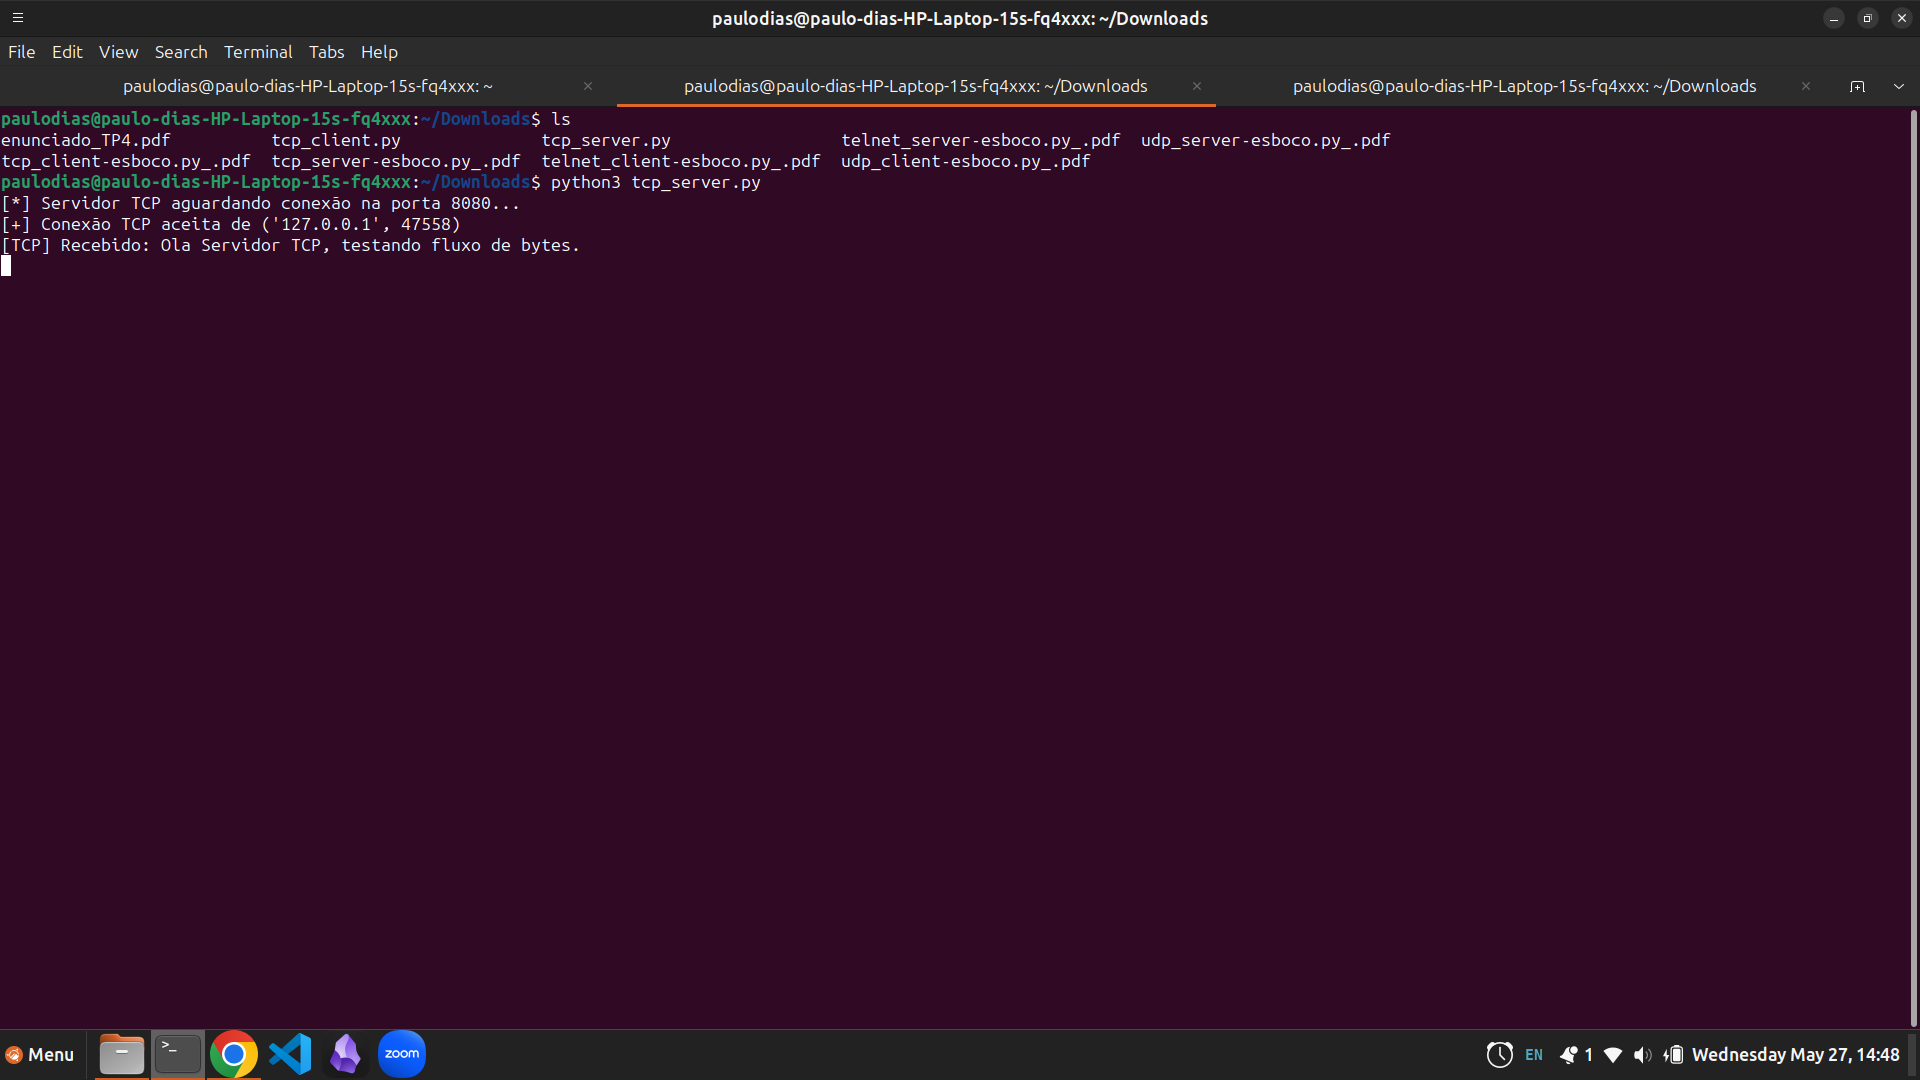

Print cliente, que mandou a informacao ao servidor:
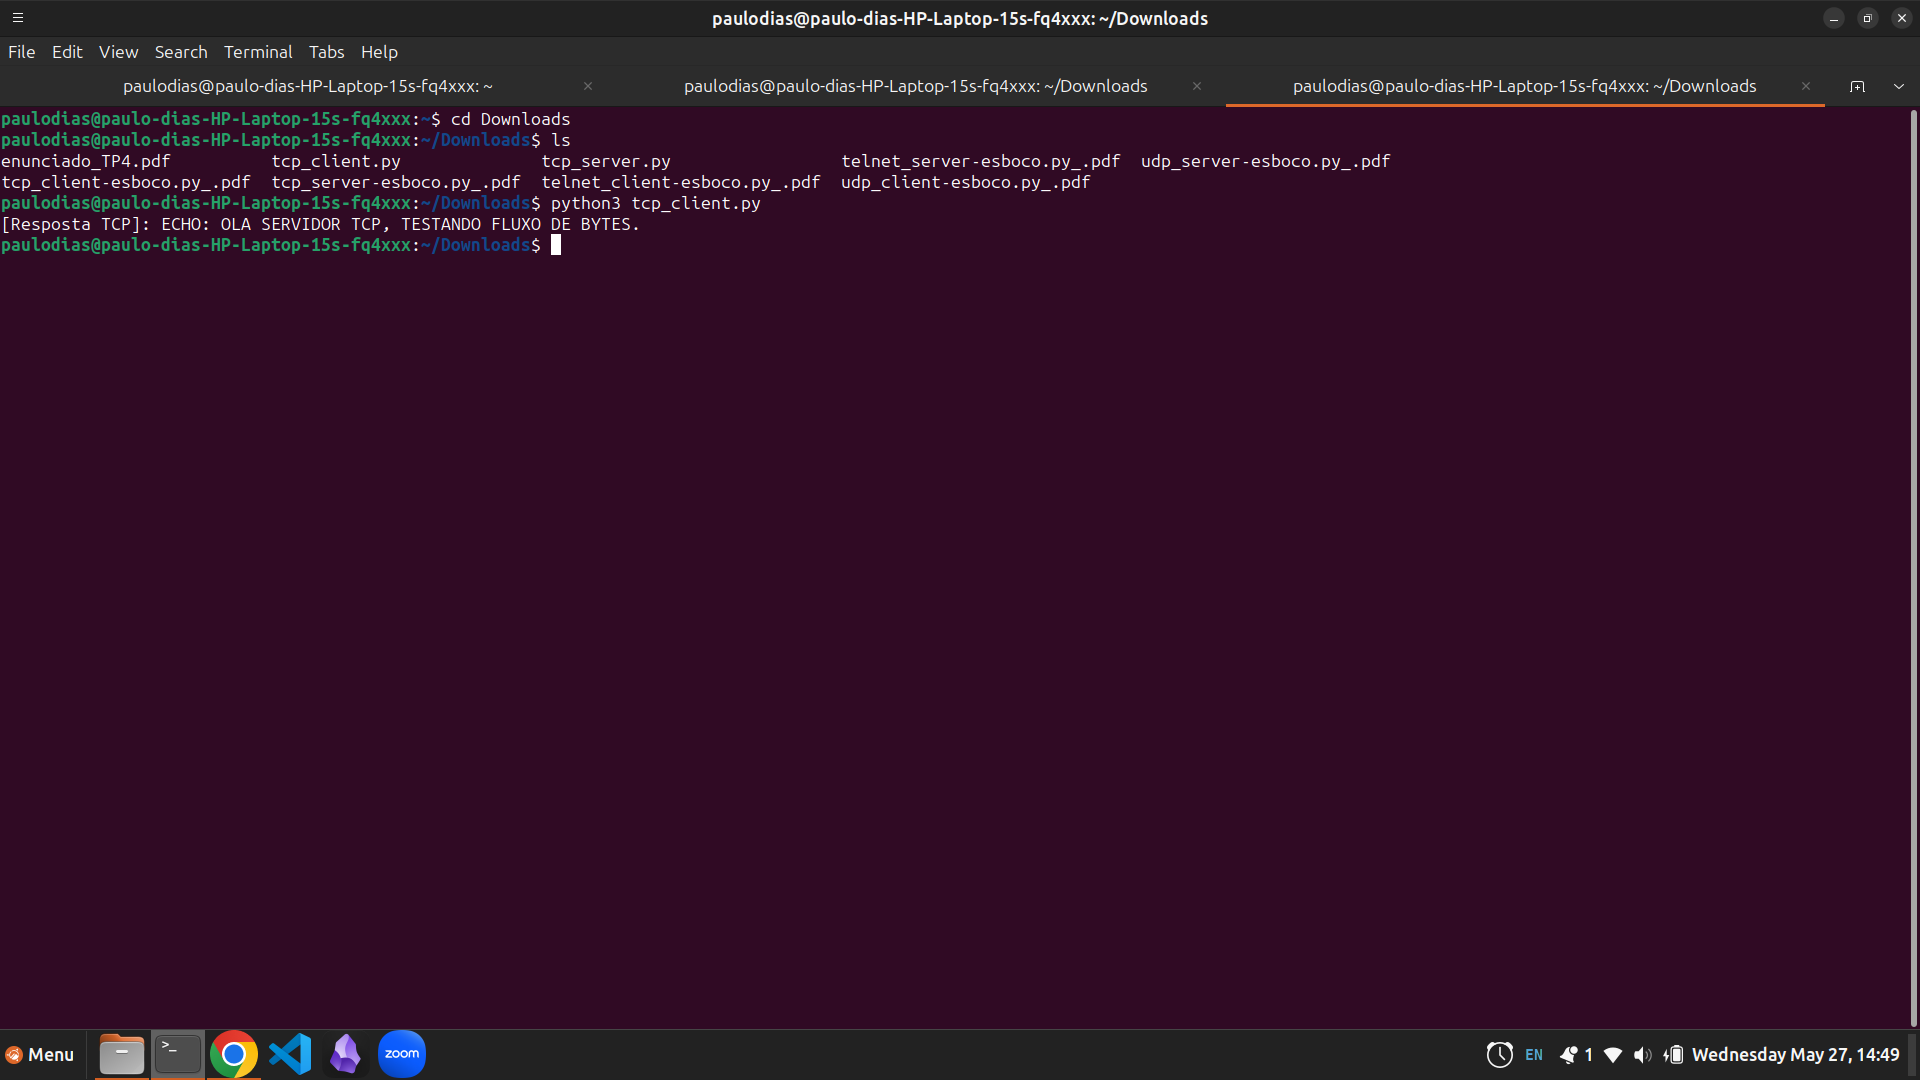

Seguindo o mesmo principio do anterior, somente alterei a porta do server em client para loopback '127.0.0.1'

udp_server.py

    import socket
    HOST = '0.0.0.0'
    PORT = 8081 # Usando uma porta diferente para o UDP
    # AF_INET = IPv4 | SOCK_DGRAM = UDP
    server_udp = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    server_udp.bind((HOST, PORT))
    print(f"[*] Servidor UDP pronto na porta {PORT}...")
    while True:
        # recvfrom retorna os dados E o endereço (IP, Porta) do remetente
        data, client_addr = server_udp.recvfrom(1024)
        mensagem = data.decode('utf-8')
        print(f"[UDP] Recebido de {client_addr}: {mensagem}")
        resposta = f"ECHO UDP: {mensagem.upper()}".encode('utf-8')
        # UDP exige dizer explicitamente para quem enviar cada pacote
        server_udp.sendto(resposta, client_addr)


udp_client.py

    import socket
    SERVER_IP = '192.168.1.50' # Exemplo de IP do Computador B
    PORT = 8081
    client_udp = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    msg = "Ola Servidor UDP, testando datagrama unico."
    \# Envia direto, sem estabelecer conexão prévia
    client_udp.sendto(msg.encode('utf-8'), (SERVER_IP, PORT))
    \# Aguarda a resposta do servidor
    resposta, server_addr = client_udp.recvfrom(1024)
    print(f"[Resposta UDP de {server_addr}]: {resposta.decode('utf-8')}")
    client_udp.close()

UDP Server
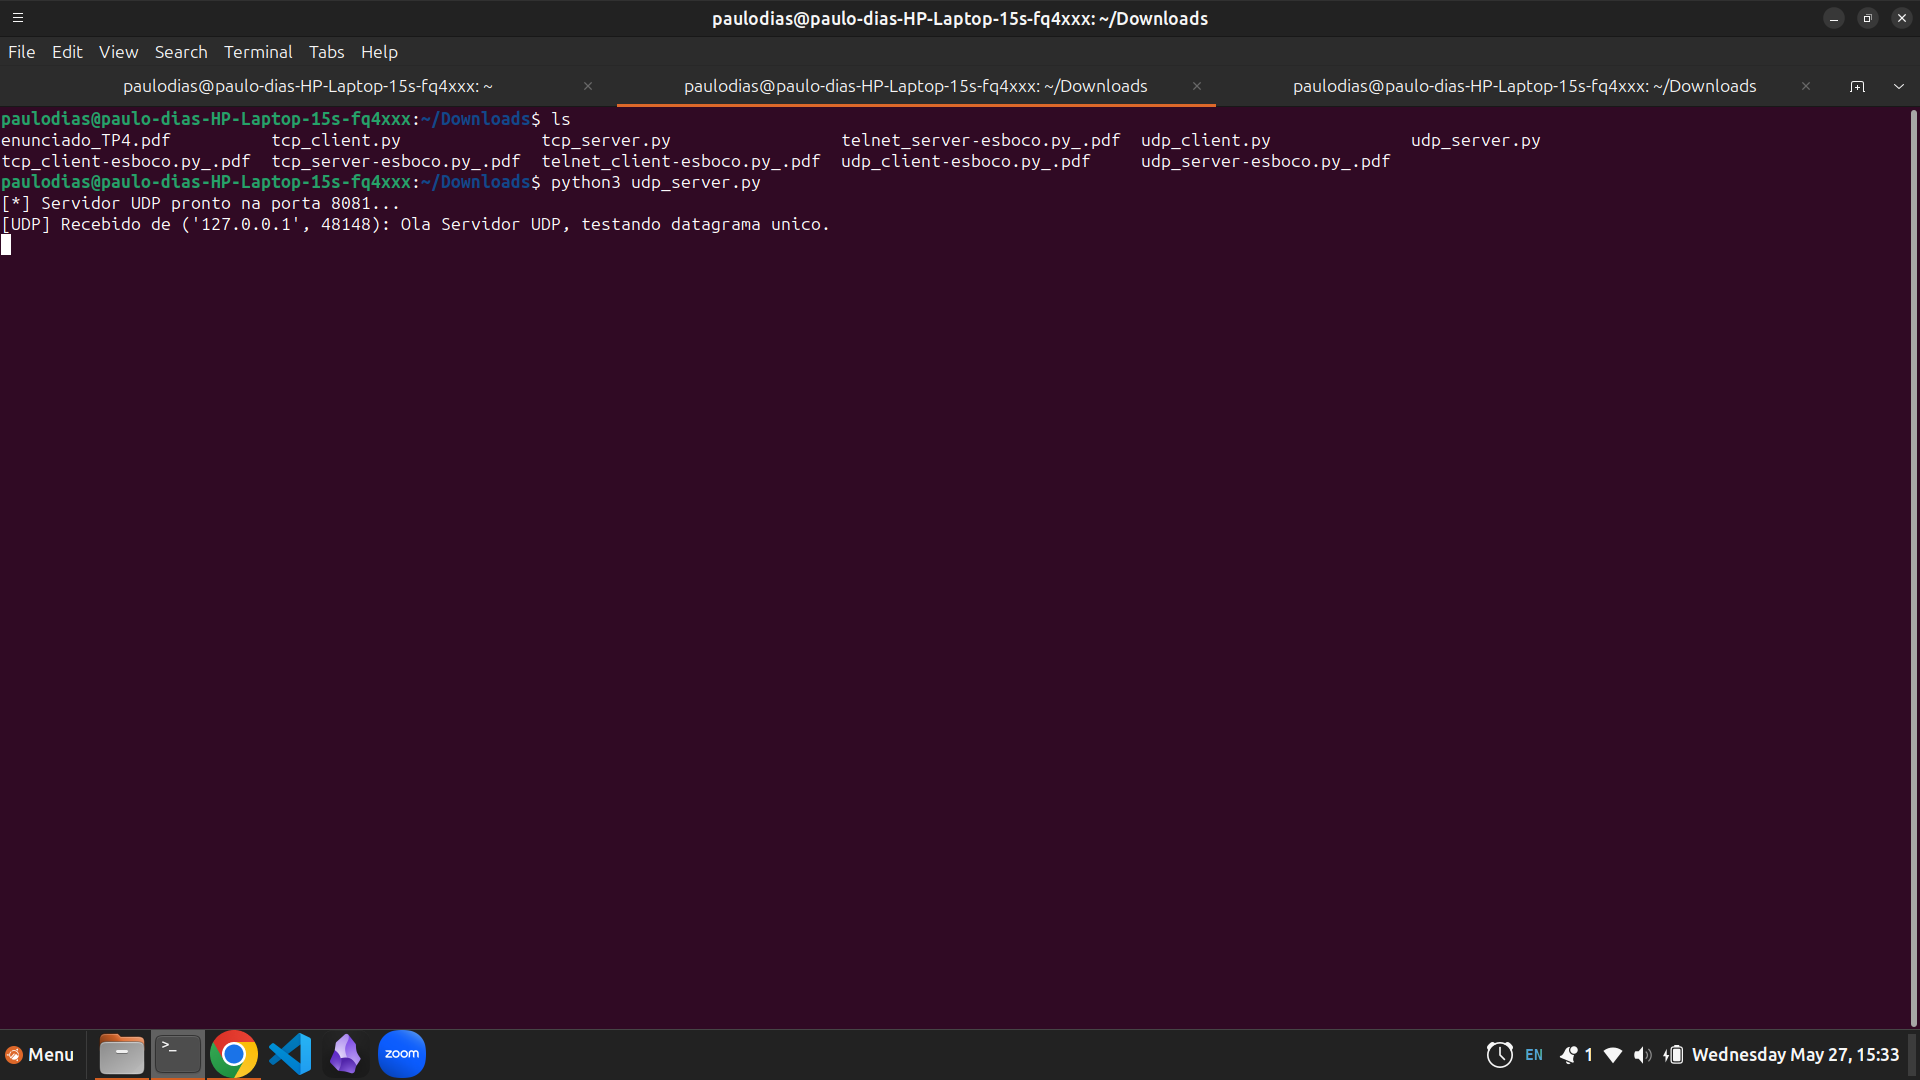

UDP Client
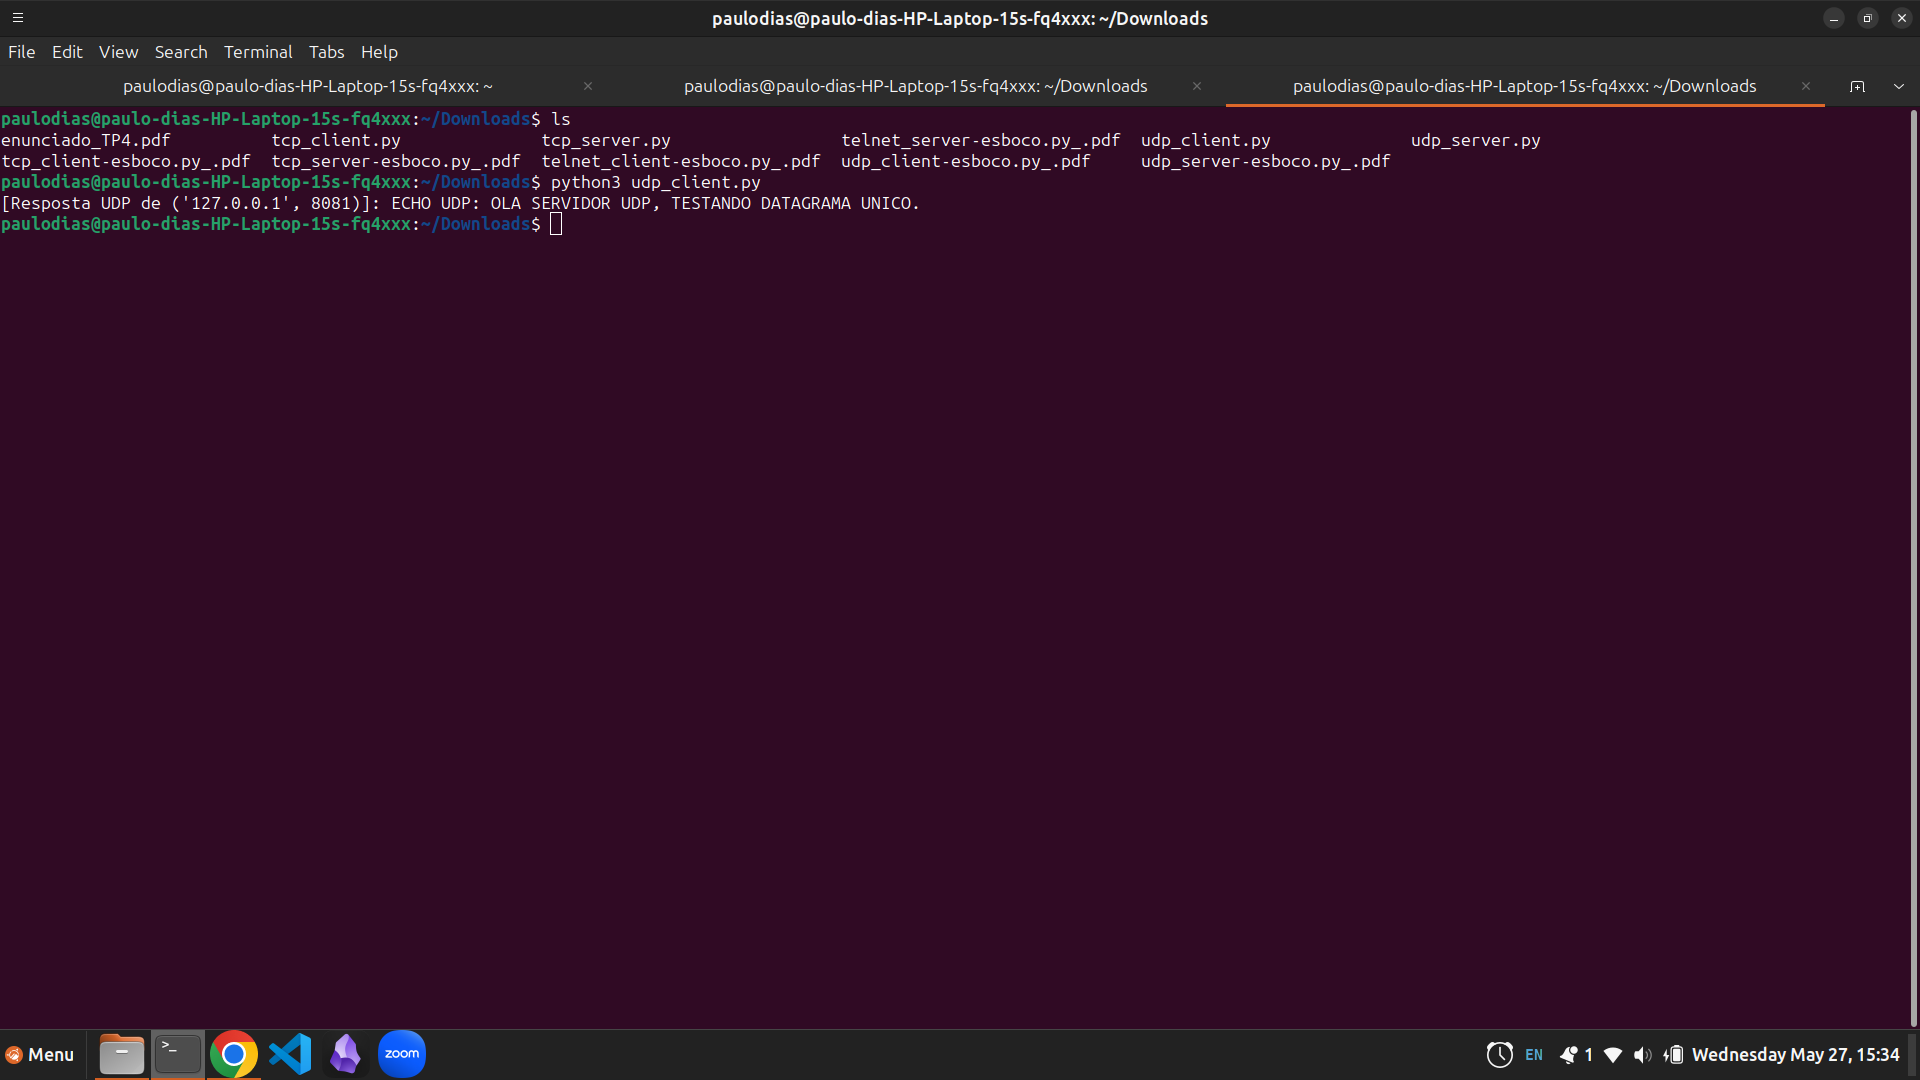

### Exercício 5

Implementando e analisando aplicações Telnet:
* Implemente um cliente Telnet e hospede-o em um computador “A”.
* Implemente um servidor Telnet e hospede-o em um computador “B”.
* Execute testes de comunicação cliente-servidor utilizando seus programas dos itens (i) e (ii). Documente os resultados.
* Escreva um programa que utilize o curl para analisar o comportamento das aplicações cliente e servidor implementadas nos itens (i) e (ii).

Para este exercicio, novamente executo os experimentos na porta localhost '127.0.0.1' alterando o codigo presente na variavel SERVER em telnet_client.py.
    
    import socket
    import sys
    import threading
    SERVER_IP = '127.0.0.1'
    PORT = 2323
    # Substituir pelo IP do Computador B
    client = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    client.connect((SERVER_IP, PORT))
    # Thread dedicada apenas para escutar o que o servidor envia e printar na tela
    def escutar_servidor():
    	while True:
    		try:
    			dados = client.recv(1024)
    			if not dados:
    				print("\n[-] Conexão encerrada pelo servidor.")
    				break
    			# Exibe na tela sem pular linha automática (respeitando o buffer do servidor)
    			sys.stdout.write(dados.decode('utf-8'))
    			sys.stdout.flush()
    		except:
    			break
    thread_escuta = threading.Thread(target=escutar_servidor, daemon=True)
    thread_escuta.start()
    # Loop principal envia os comandos digitados pelo usuário
    try:
    	while True:
    		comando = input()
    		client.sendall((comando + '\n').encode('utf-8'))
    		if comando.lower() == 'exit':
    			break
    except KeyboardInterrupt:
    	print("\n[-] Fechando cliente.")
    finally:
    	client.close()


telnet_server.py
    
    import socket
    import subprocess
    
    HOST = '0.0.0.0'
    PORT = 2323
    
    server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    server.bind((HOST, PORT))
    server.listen(1)
    
    print(f"[*] Servidor Telnet Educacional aguardando conexões na porta {PORT}...")
    
    while True:
        client_sock, client_addr = server.accept()
        print(f"[+] Conexão Telnet estabelecida com: {client_addr}")
        client_sock.sendall(b"--- Bem-vindo ao Servidor Telnet Educacional ---\n$ ")
    
        try:
            while True:
                data = client_sock.recv(1024)
                if not data:
                    break
    
                comando = data.decode('utf-8').strip()
    
                if comando.lower() == 'exit':
                    client_sock.sendall(b"Encerrando sessao. Ate logo!\n")
                    break
    
                if comando:
                    print(f"[Executando]: {comando}")
                    try:
                        saida = subprocess.check_output(
                            comando, shell=True, stderr=subprocess.STDOUT
                        )
                    except subprocess.CalledProcessError as e:
                        saida = e.output
    
                    client_sock.sendall(saida + b"\n$ ")
                else:
                    client_sock.sendall(b"$ ")
    
        except Exception as e:
            print(f"[-] Erro na conexao: {e}")
        finally:
            client_sock.close()
            print(f"[-] Conexão com {client_addr} encerrada.")

Essa codificacao resulta no seguinte:

porta servidor

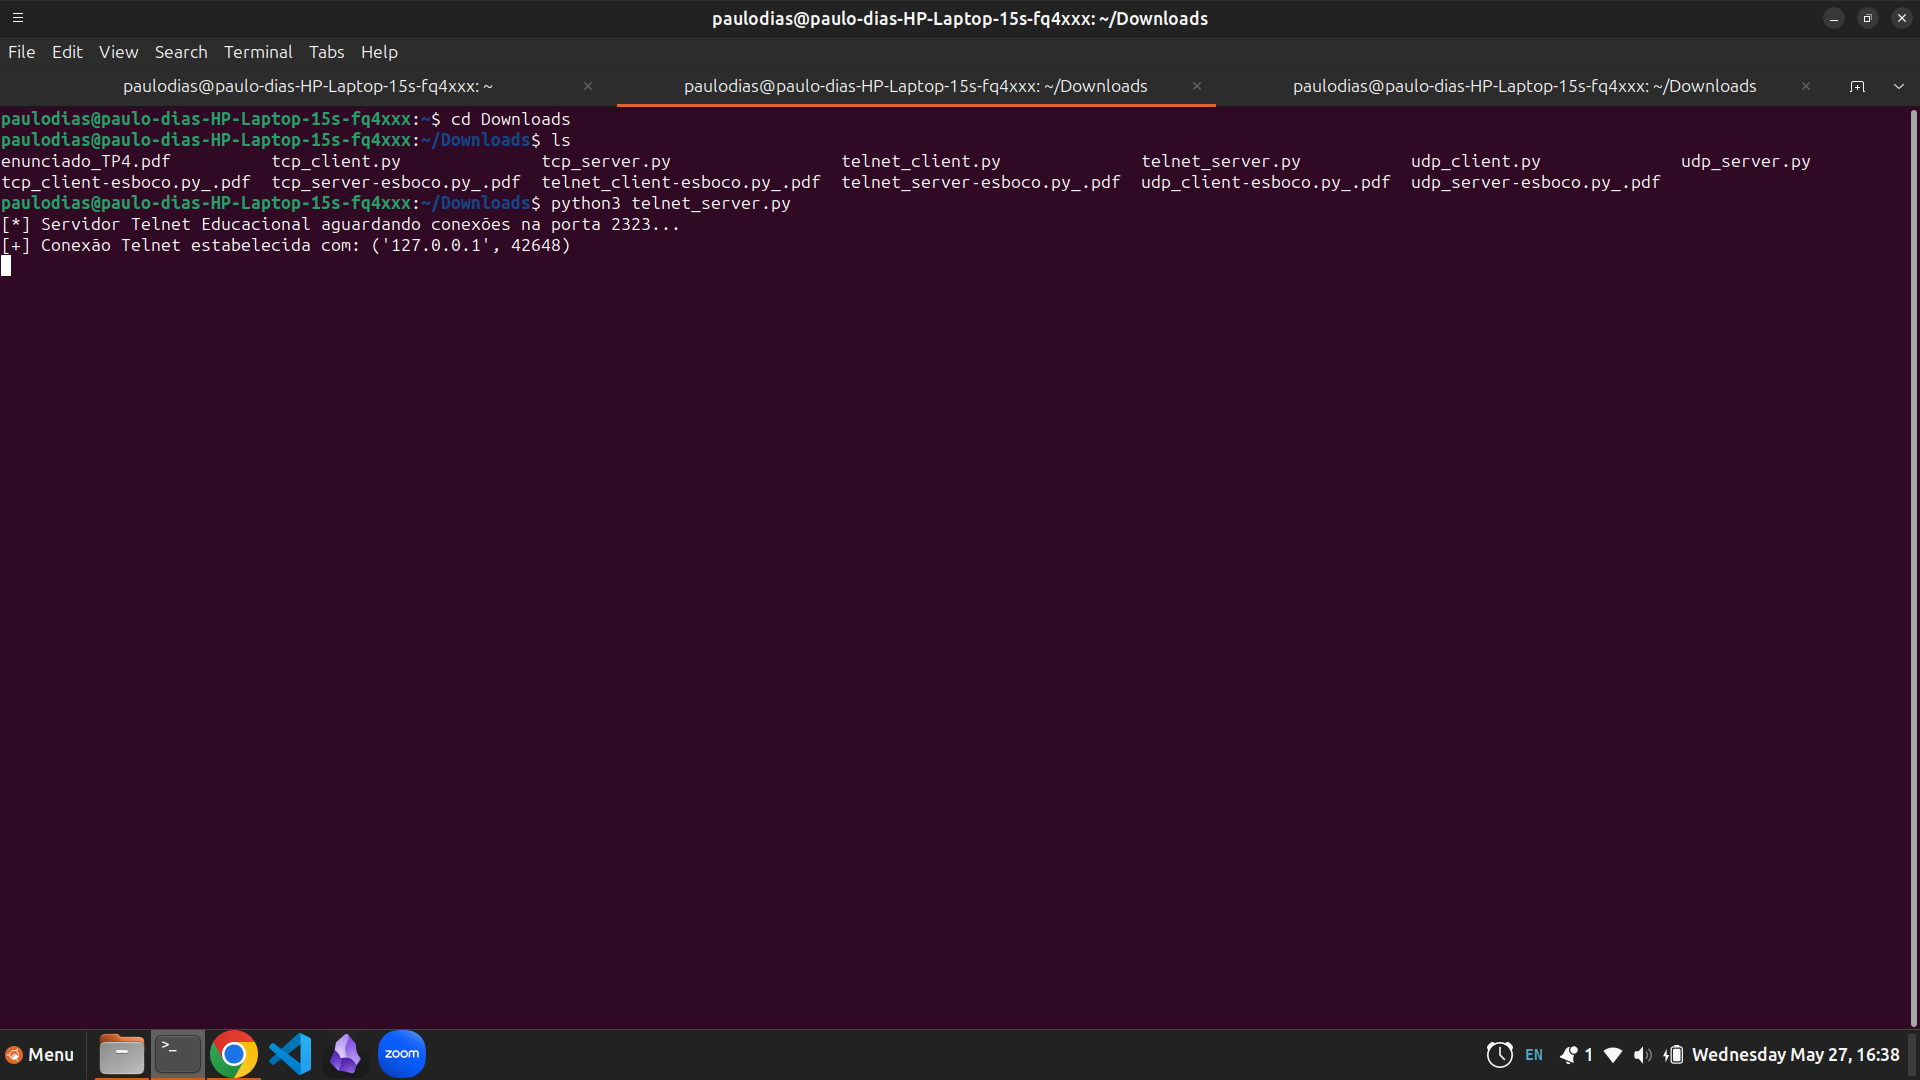

Porta Cliente

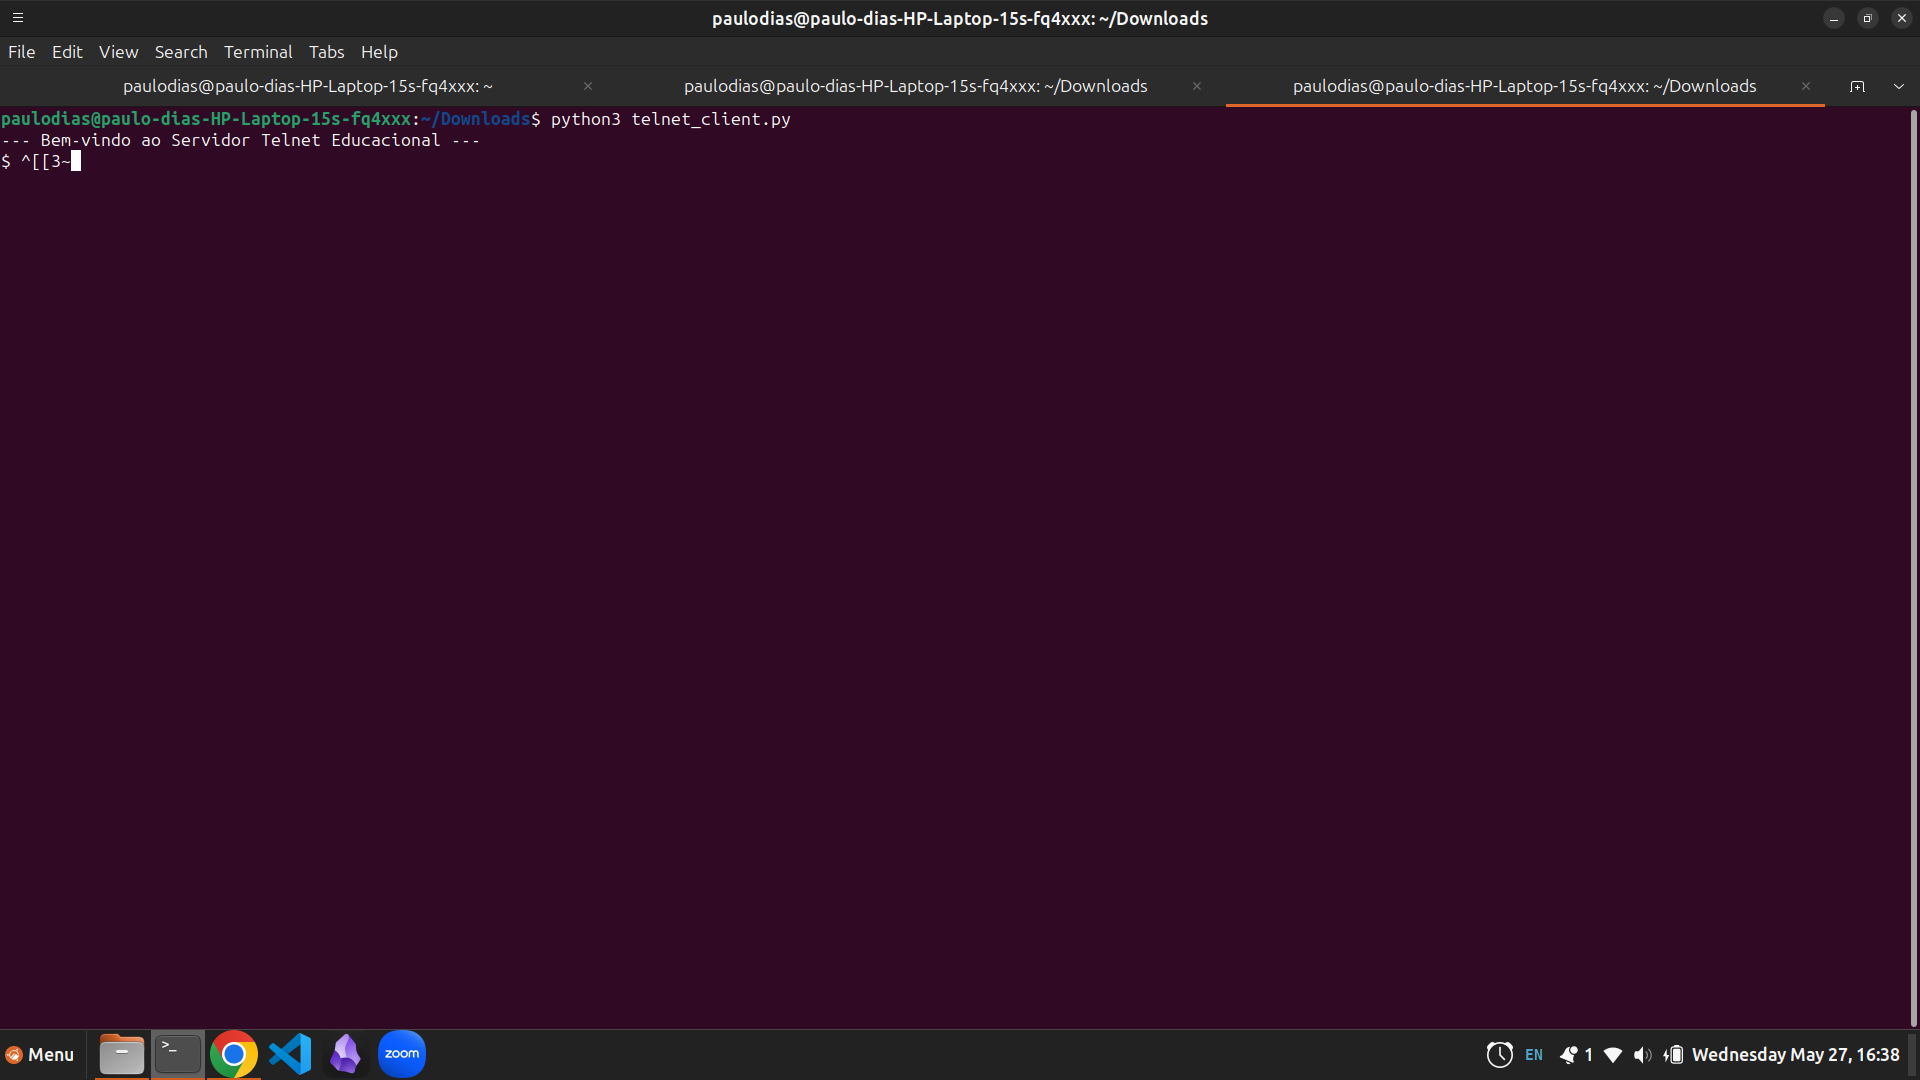

Alguns comando para verificacao partindo do lado do cliente foram ls, touch e ls novamente:

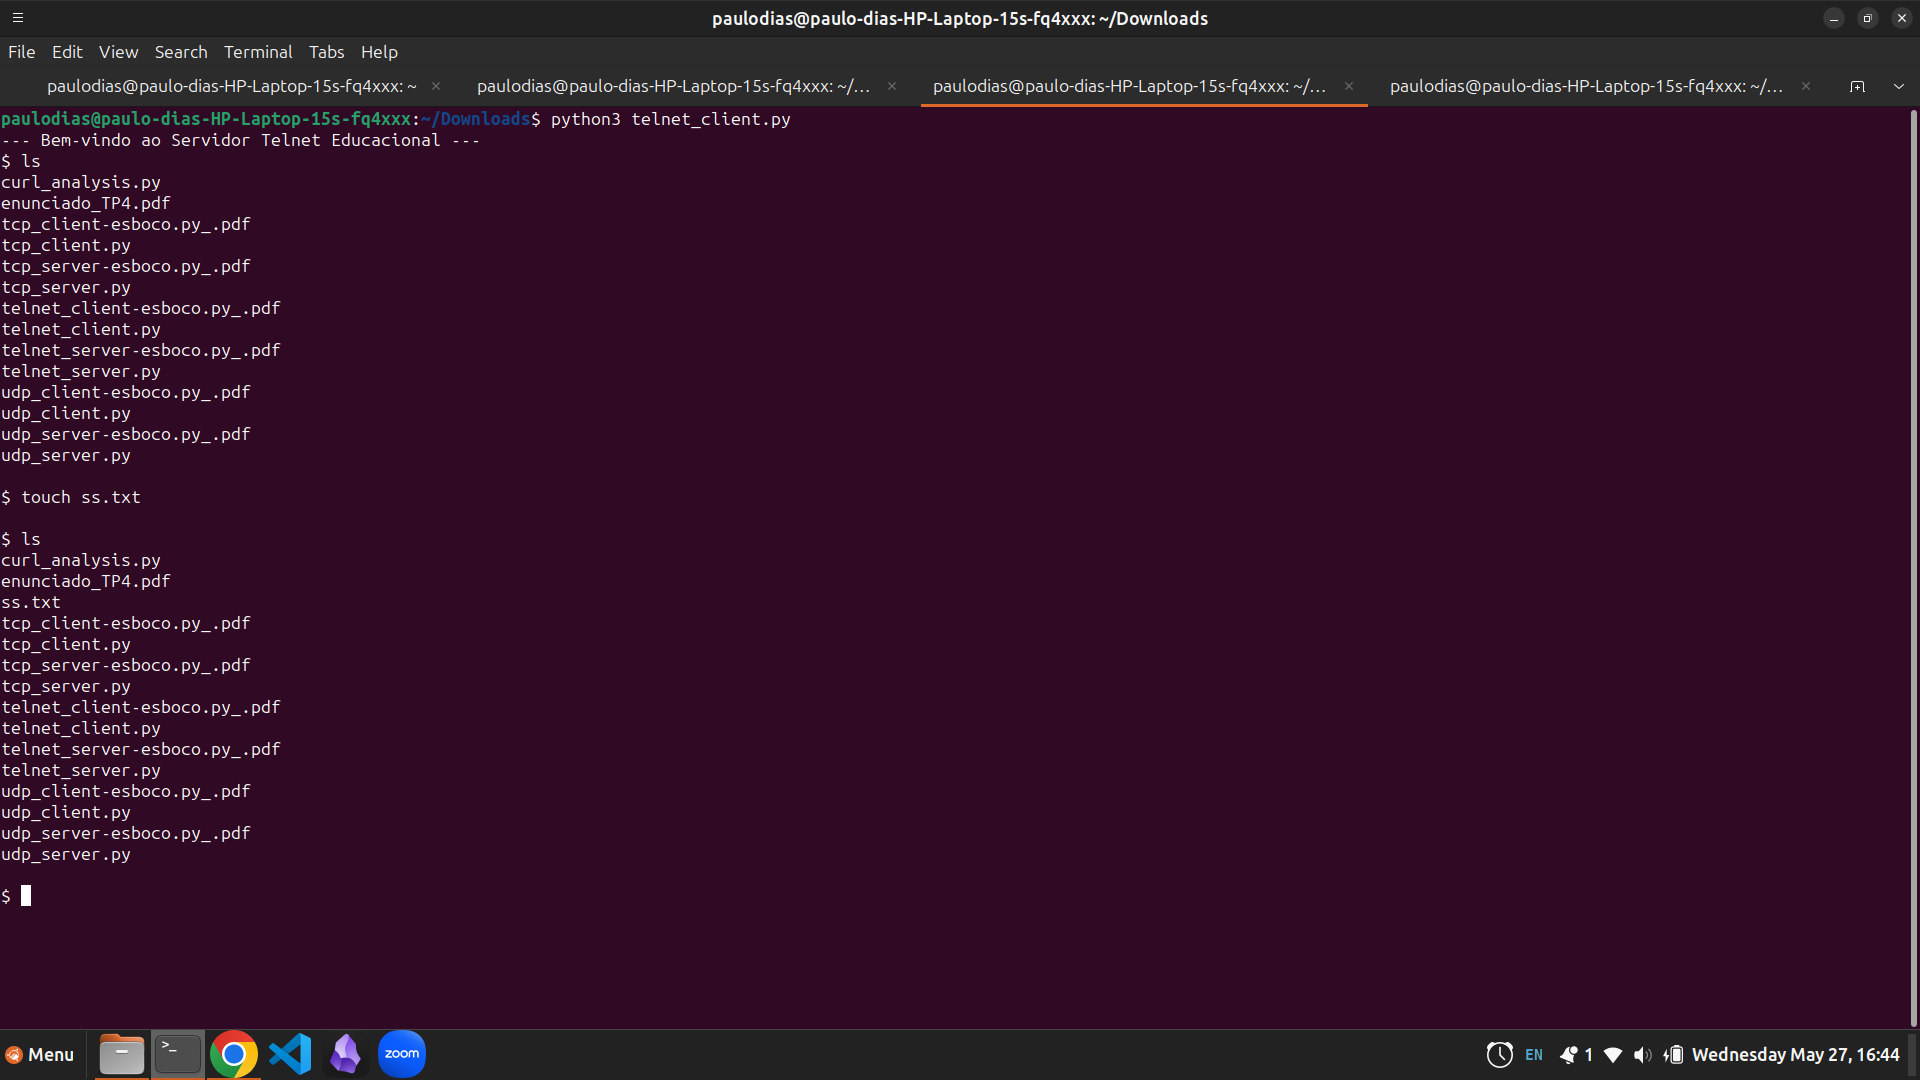

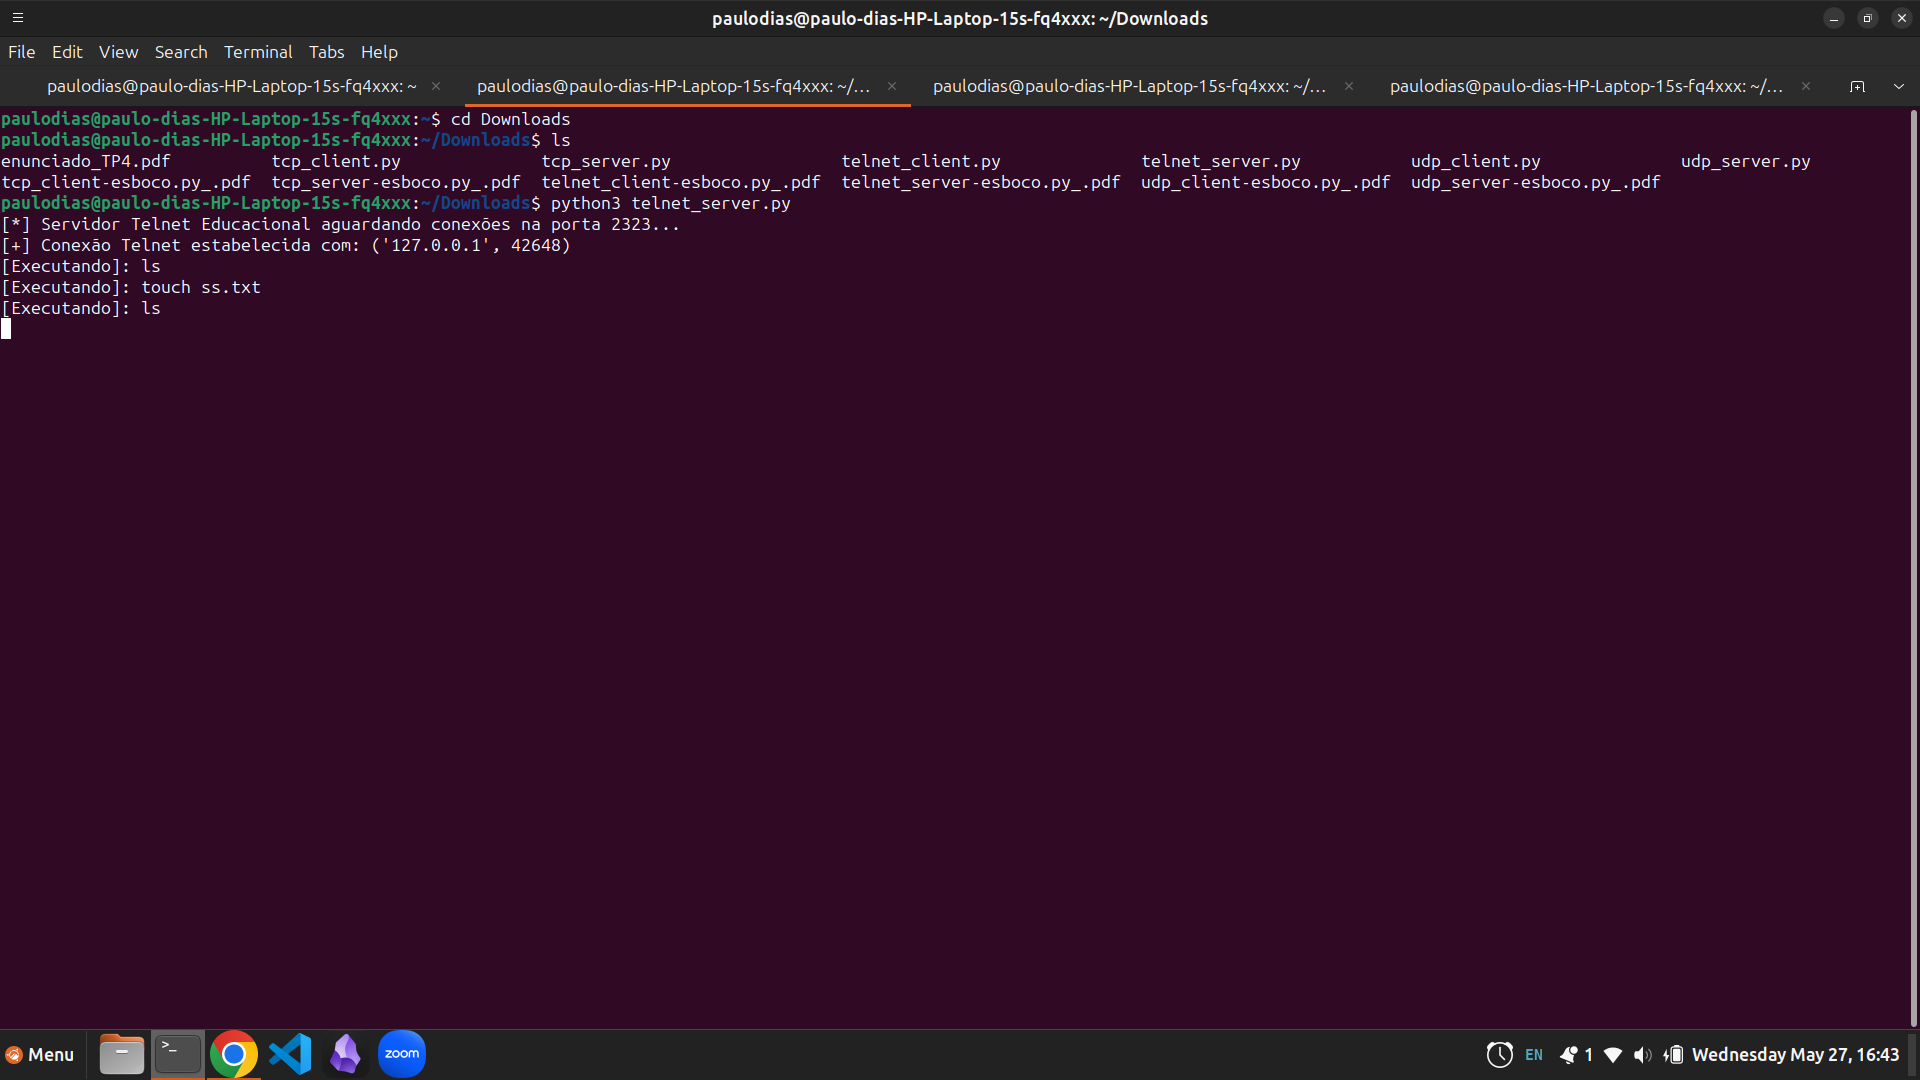

Para analise da diferenca entre requisicoes utilizando o CURL especificos do enunciado, utilizei o seguinte:

    import subprocess
    import time
    
    SERVER = '127.0.0.1'
    PORT   = 2323
    
    testes = [
        {
            "descricao": "Tentar conectar via curl (protocolo errado — curl espera HTTP)",
            "comando": f"curl -v telnet://{SERVER}:{PORT}",
        },
        {
            "descricao": "Forcar curl a enviar texto puro via --data (simula linha de comando)",
            "comando": f'curl -v --data "echo hello" telnet://{SERVER}:{PORT}',
        },
        {
            "descricao": "Timeout curto para ver resposta inicial do servidor",
            "comando": f"curl -v --max-time 3 telnet://{SERVER}:{PORT}",
        },
    ]
    
    for teste in testes:
        print("=" * 60)
        print(f"TESTE : {teste['descricao']}")
        print(f"CMD   : {teste['comando']}")
        print("-" * 60)
    
        resultado = subprocess.run(
            teste["comando"],
            shell=True,
            capture_output=True,
            text=True
        )
    
        saida = resultado.stdout + resultado.stderr
        print(saida if saida.strip() else "(sem saída)")
        time.sleep(1)
    
    print("=" * 60)
    print("[*] Análise curl concluída.")

Resultando no seguinte:

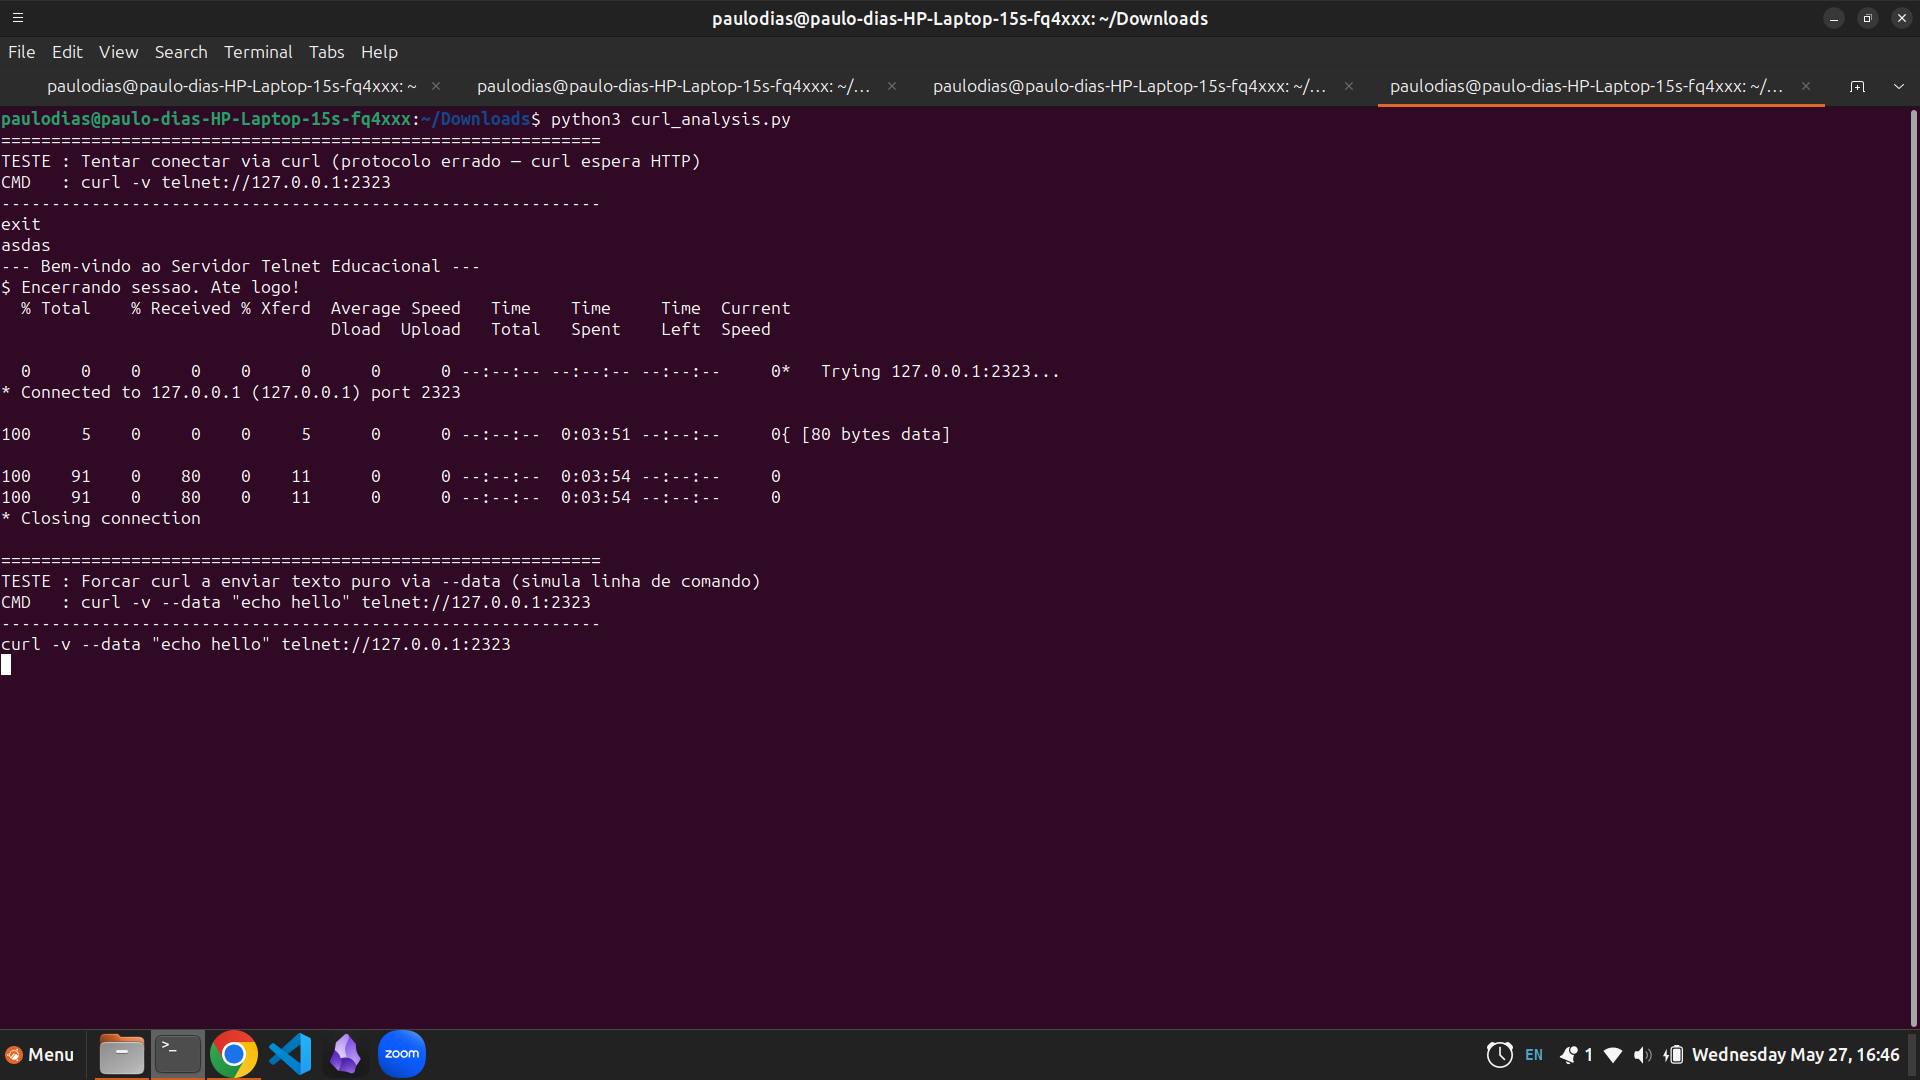

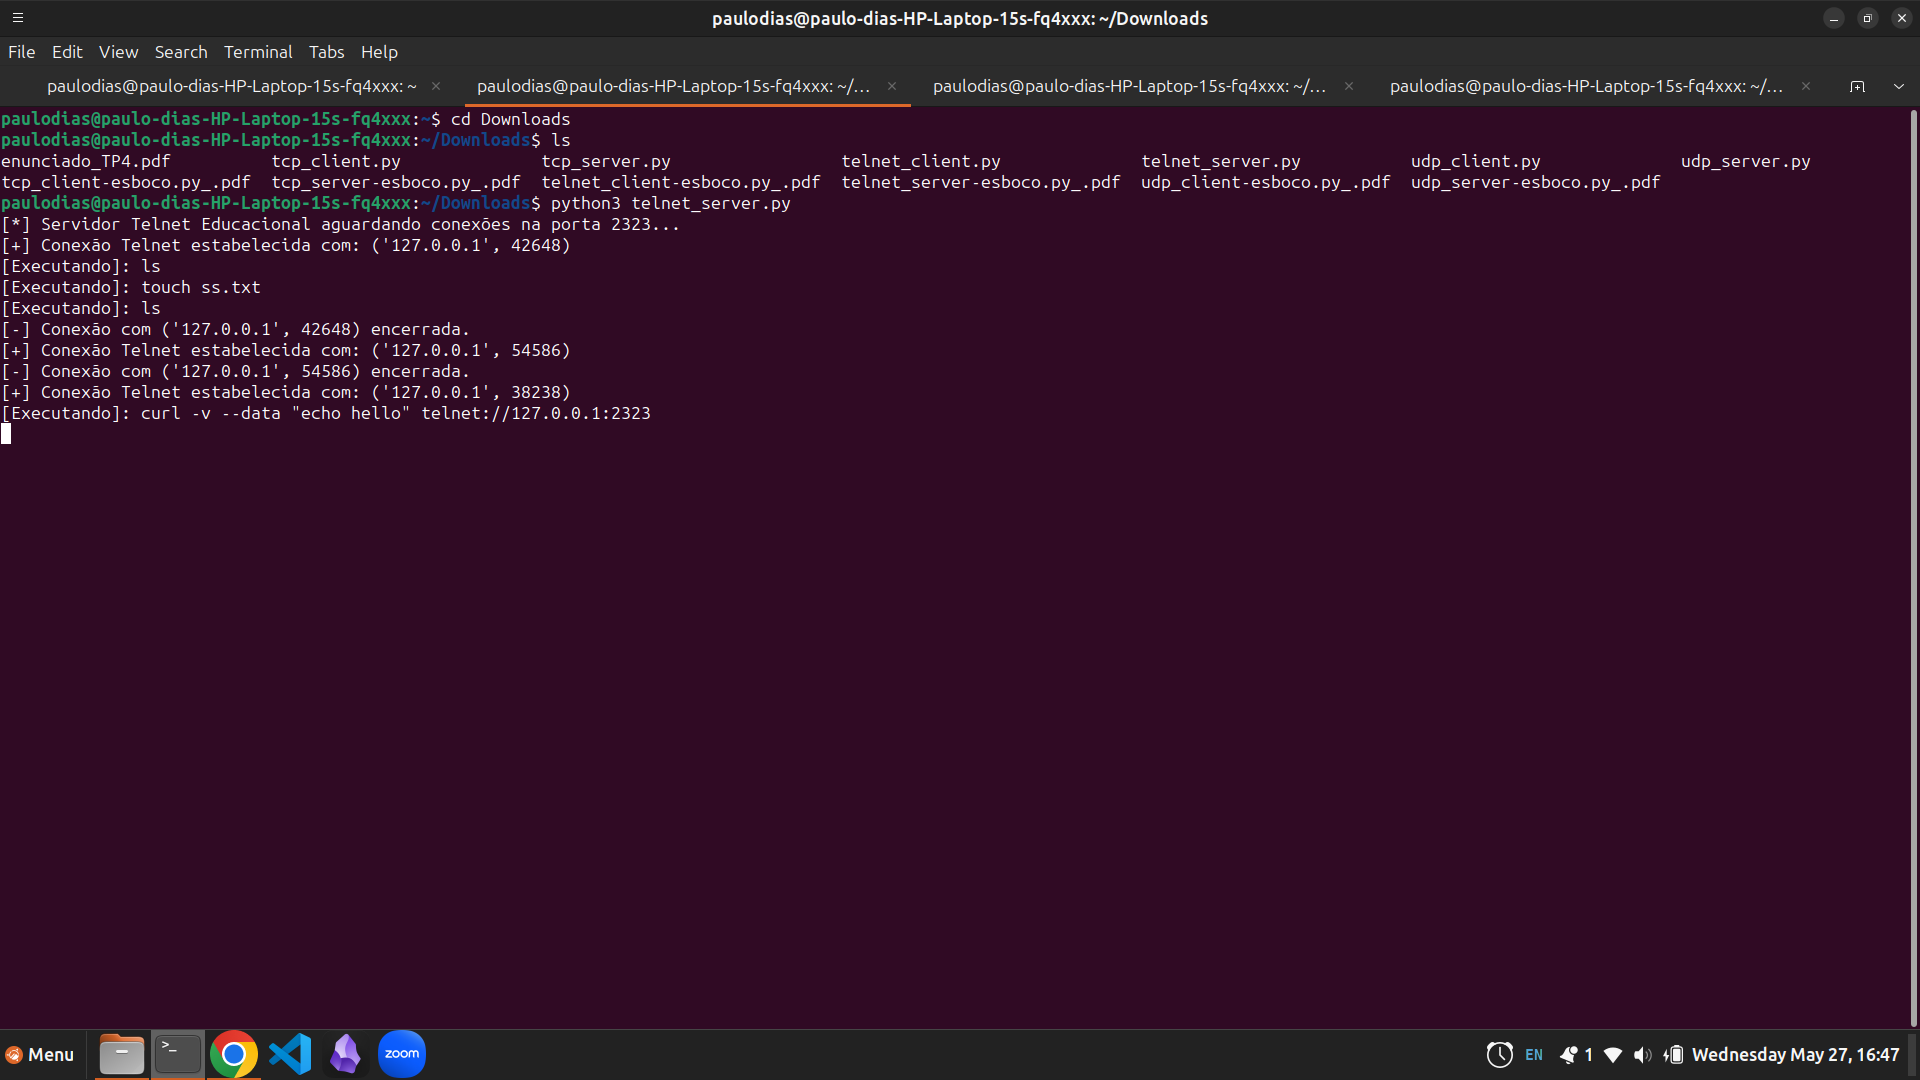